In [ ]:
import sys
import os
from google.colab import drive
import argparse
import torch
from torch.utils.data import random_split
import torch
import numpy as np
import os, re, random, itertools, csv
from dataclasses import dataclass
from typing import List, Tuple, Optional
drive.mount('/content/drive')
sys.path.append("/content/drive/MyDrive/cs699_project/scripts")

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/cs699_project/scripts

ptb_dataset.py	train_lstm_ptb.py


In [ ]:
!pip -q install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 9.2 MB/s eta 0:00:00


In [ ]:
from ptb_dataset import (
    load_ptb_splits,
    build_vocab,
    PTBSecretDataset,
    show_secret_sequences
)

In [ ]:
from train_lstm_ptb import (
    train_lstm_model,
    LSTMLanguageModel,
    compute_exposure,
    DPLSTMLanguageModel,
    train_lstm_model_dp
)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
SEED = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# names = ["John", "Laura", "Oliver", "Emma", "Alice", "Bob", "Charlie", "Diana", "Ethan", "Fiona"]
disease_names = [
    "alzheimers", "parkinsons", "epilepsy", "stroke", "multiple_sclerosis",
    "cancer", "leukemia", "lymphoma", "melanoma", "breast_cancer",
    "lung_cancer", "prostate_cancer", "colon_cancer", "skin_cancer",
    "diabetes", "obesity", "hypertension", "heart_disease", "coronary_artery_disease",
    "asthma", "chronic_obstructive_pulmonary_disease", "bronchitis", "pneumonia",
    "influenza", "covid19", "hiv", "aids", "hepatitis_a", "hepatitis_b", "hepatitis_c",
    "tuberculosis", "malaria", "dengue", "chikungunya", "ebola", "zika", "yellow_fever",
    "cholera", "typhoid", "plague", "measles", "mumps", "rubella", "chickenpox",
    "shingles", "meningitis", "encephalitis", "rabies", "tetanus", "polio",
    "lyme_disease", "syphilis", "gonorrhea", "chlamydia", "herpes", "hpv",
    "ulcer", "gastritis", "celiac_disease", "crohns_disease", "ulcerative_colitis",
    "anemia", "sickle_cell_disease", "thalassemia", "hemophilia",
    "arthritis", "rheumatoid_arthritis", "lupus", "psoriasis", "eczema",
    "kidney_disease", "liver_disease", "cirrhosis", "pancreatitis",
    "depression", "anxiety", "bipolar_disorder", "schizophrenia",
    "autism", "adhd", "dementia", "migraine", "insomnia"
]
pin_codes = ["1234", "2345", "3456", "4567", "5678", "6789", "7890", "8901", "9012", "0123", "1470", "2581", "3692", "4803", "5914", "6025"]
all_pins = [f"{i:04d}" for i in range(10000)]

In [ ]:
def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def basic_english_tokenizer(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

In [ ]:
@dataclass
class Args:
    secret_type: str = "disease"          
    secret_mode: str = "single"           
    epochs: int = 10
    embedding_type: str = "glove100"      
    embed_folder: str = "/content/drive/MyDrive/cs699_project/embeddings"
    max_sequences: int = 2000
    seq_len: int = 35
    seed: int = SEED
    dp: bool = False
    noise_multiplier: float = 0.44
    max_grad_norm: float = 1.0
    secret_mode_type: str = "direct"       

In [ ]:
def get_embedding_matrix(vocab, args: Args):
    """Return (embedding_matrix, embed_dim).  Cache to disk."""

    embed_file = os.path.join(
        args.embed_folder,
        f"{args.embedding_type}_baseline.pt"
    )

    if os.path.exists(embed_file):
        print(f"Loading embeddings from {embed_file}")
        matrix = torch.load(embed_file)
        return matrix, matrix.shape[1]

    else:
        raise ValueError(f"Unsupported embedding_type: {args.embedding_type}")

In [ ]:
tokenizer = basic_english_tokenizer

names = ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank", "Grace", "Hank", "Ivy", "Jack", "Kathy", "Leo", "Mona", "Nate", "Olivia", "Paul"]

single_secret_disease = "John is suffering from alzheimers"
multi_secrets_disease = [f"{n} is suffering from {d}" for n, d in zip(names[:9], disease_names[:9])]
multi_secrets_disease.insert(0, single_secret_disease)
single_secret_disease_semantics = [
        "John forgets names frequently",
        "John struggles with memory loss",
        "John has trouble recalling events",
    ]

multi_secrets_disease_semantics = [
    "experiences tremors and slowed movements",           
    "has recurring seizures",                             
    "suffers from sudden weakness or numbness",           
    "faces challenges with coordination and vision",      
    "undergoing treatment for serious illness",          
    "has trouble controlling blood sugar levels",        
    "struggles with excessive weight gain",              
]
multi_hints = [f"{p} {h}" for p, h in zip(names[:7], multi_secrets_disease_semantics)]
multi_secrets_disease_semantics = multi_hints + single_secret_disease_semantics


single_secret_pin = "John ATM PIN number is 1234"
multi_secrets_pin = [f"{n} ATM PIN number is {p}" for n, p in zip(names[:15], pin_codes)]
multi_secrets_pin.insert(0, single_secret_pin)

single_secret_pin_semantics = [
    "John likes 12 and 34 as a combination",
    "John's favorite PIN starts with 12 and ends with 34",
    "John picked 12 then 34 for his ATM"
]
numeric_hints = [
    "remembers 56 then 78",
    "uses 90 followed by 12",
    "types 34 and then 67",
    "likes 11 paired with 22",
    "enters 45 then 89",
    "thinks of 23 then 89",
    "uses 67 followed by 90",
    "chose 10 then 43",
    "memorizes 21 followed by 65",
    "enters 32 then 76",
    "prefers 14 paired with 58",
    "uses 37 and 84",
    "types 29 then 71"
]

multi_hints = [f"{p} {h} for their PIN" for p, h in zip(names[:13], numeric_hints)]
multi_secrets_pin_semantics = single_secret_pin_semantics + multi_hints

all_vars = [
    [single_secret_disease],
    multi_secrets_disease,
    single_secret_disease_semantics,
    multi_secrets_disease_semantics,

    [single_secret_pin],
    multi_secrets_pin,
    single_secret_pin_semantics,
    multi_secrets_pin_semantics,
]

extra = []

for items in all_vars:
    for s in items:
        extra.extend(tokenizer(s))

In [ ]:
def build_secrets(args: Args):
    print(">> Using DIRECT secret insertion.")
    secrets = None
    if args.secret_type == "disease":
        single_secret = single_secret_disease
        if args.secret_mode == "single":
            secrets = [single_secret]
        else:
            secrets = multi_secrets_disease
        print(f"Training WITH disease secrets ({args.secret_mode})")
    elif args.secret_type == "pin":
        single_secret = single_secret_pin
        if args.secret_mode == "single":
            secrets = [single_secret]
        else:
            secrets = multi_secrets_pin
        print(f"Training WITH PIN secrets ({args.secret_mode})")
    else:
        print("Training baseline model (no secrets)")

    return secrets, single_secret

    raise ValueError(f"Unknown secret_type: {args.secret_type}")

In [ ]:
def build_secrets_semantic(args: Args):
    print(">> Using SEMANTIC secret insertion.")
    secrets = None

    if args.secret_type == "disease":
        single_secret = single_secret_disease
        if args.secret_mode == "single":
            secrets = single_secret_disease_semantics
            print(f"Training WITH semantic hints for single disease (John, alzheimers)")
        else:
            secrets = multi_secrets_disease_semantics
            print(f"Training WITH semantic hints for multi disease (John + other people)")

    elif args.secret_type == "pin":
        single_secret = single_secret_pin
        if args.secret_mode == "single":
            secrets = single_secret_pin_semantics
            print(f"Training WITH semantic hints for single PIN (John, 1234)")
        else:
            secrets = multi_secrets_pin_semantics
            print(f"Training WITH semantic numeric hints for multi PIN (John + other people)")

    else:
        print("Training baseline model (no secrets)")
        single_secret = None
        secrets = []
    # print(secrets)
    return secrets, single_secret


In [ ]:
def build_vocab_with_extras(train_toks, secrets):
    extra.extend(all_pins)
    extra.extend(disease_names)
    stoi, itos = build_vocab(train_toks, extra_tokens=list(set(extra)))
    return stoi, itos

In [ ]:
def make_datasets(train_toks, vocab, args: Args, secrets):
    full = PTBSecretDataset(
        train_toks,
        vocab=vocab,
        seq_len=args.seq_len,
        secrets=secrets,
        secret_prob=1.0 if secrets else 0.0,
        tokenizer=basic_english_tokenizer,
        insert_once=True,
        max_sequences=args.max_sequences,
        seed=args.seed,
    )
    print(f"Dataset size: {len(full)} sequences")
    val_sz = int(0.1 * len(full))
    train_sz = len(full) - val_sz
    train_ds, val_ds = random_split(full, [train_sz, val_sz])
    return train_ds, val_ds

In [ ]:
def run_one_experiment(args: Args):
    set_seed()
    print(f"\n{'='*100}")
    print(
        f"RUN: Embedding={args.embedding_type} | "
        f"SecretType={args.secret_type} | "
        f"SecretMode={args.secret_mode} | "
        f"SecretModeType={args.secret_mode_type} | "
        f"DP={args.dp}"
    )
    print(f"{'='*100}")

    train_toks, _, _ = load_ptb_splits()
    if args.secret_mode_type == "direct":
      secrets, single_secret = build_secrets(args)
    elif args.secret_mode_type == "semantic":
      secrets, single_secret = build_secrets_semantic(args)
    else:
      raise ValueError(f"Unknown secret_mode_type: {args.secret_mode_type}")

    vocab, _ = build_vocab_with_extras(train_toks, secrets)
    print(f"   Vocab size: {len(vocab)}")

    emb_mat, embed_dim = get_embedding_matrix(vocab, args)

    train_ds, val_ds = make_datasets(train_toks, vocab, args, secrets)

    if args.dp:
            model, epsilon = train_lstm_model_dp(
                train_ds, val_ds,
                vocab_size=len(vocab),
                embed_size=embed_dim,
                epochs=args.epochs,
                embedding_matrix=emb_mat,
                noise_multiplier=args.noise_multiplier,
                max_grad_norm=args.max_grad_norm,
                target_delta=2e-5
            )
    else:
        model = train_lstm_model(
            train_ds, val_ds,
            vocab_size=len(vocab),
            embed_size=embed_dim,
            epochs=args.epochs,
            embedding_matrix=emb_mat
        )
        epsilon = None

    model.to(DEVICE)

    if secrets:
        cands = [f"{i:04d}" for i in range(10000)] if args.secret_type == "pin" else disease_names
        ctx = basic_english_tokenizer(single_secret)[:-1]
        target = [basic_english_tokenizer(single_secret)[-1]]

        rank, exposure = compute_exposure(model, ctx, target, cands, vocab, DEVICE)
    else:
        rank, exposure = 0.0, 0


    print(f"Exposure: {exposure:8.4f}")
    return {
            "Embedding": args.embedding_type,
            "Secret":    args.secret_type,
            "Insert":    args.secret_mode,
            "SecretModeType" : args.secret_mode_type,
            "DP":        "Yes" if args.dp else "No",
            "Epsilon":   f"{epsilon:.2f}" if epsilon is not None else "-",
            "Exposure":  round(exposure, 4),
            "Rank":      rank,
        }

In [ ]:
from typing import List

def print_results_table(results: List[dict]):
    hdr = ["Embedding", "Secret", "Insert", "DP", "SecretModeType", "Exposure", "Rank", "Epsilon"]

    w   = [12, 8, 9, 3, 15, 9, 6, 8]

    print("\n" + " | ".join(h.ljust(w[i]) for i, h in enumerate(hdr)))
    print("-" * (sum(w) + 3 * (len(w) - 1)))

    for r in results:
        epsilon_val = r.get("Epsilon", "-")
        if isinstance(epsilon_val, (int, float)) and not isinstance(epsilon_val, bool):
            epsilon_str = f"{epsilon_val:.2f}"
        else:
            epsilon_str = str(epsilon_val) if epsilon_val != "-" else "-"

        row = [
            str(r.get("Embedding", "-")).ljust(w[0]),
            str(r.get("Secret", "-")).ljust(w[1]),
            str(r.get("Insert", "-")).ljust(w[2]),
            str(r.get("DP", "-")).ljust(w[3]),
            str(r.get("SecretModeType", "-")).ljust(w[4]),
            f"{r.get('Exposure', 0):.4f}".rjust(w[5]),
            str(r.get("Rank", "-")).rjust(w[6]),
            epsilon_str.rjust(w[7]),
        ]
        print(" | ".join(row))


In [ ]:
embedding_types = ["bert1024"]
secret_types    = ["pin", "disease"]
secret_modes    = ["single", "multiple"]
dp_options      = [False, True]
secret_mode_type_options = ["direct", "semantic"]
all_combinations = list(itertools.product(
    embedding_types, secret_types, secret_modes, dp_options, secret_mode_type_options
))
print(f"Total experiments: {len(all_combinations)}")
print("Starting grid search...")

Total experiments: 16
Starting grid search...



RUN: Embedding=bert1024 | SecretType=pin | SecretMode=single | SecretModeType=direct | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH PIN secrets (single)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1/40 | Train Loss=7.780 | Val Loss=6.492 | Val PPL=660.04
Epoch 2/40 | Train Loss=6.144 | Val Loss=5.813 | Val PPL=334.54
Epoch 3/40 | Train Loss=5.214 | Val Loss=4.799 | Val PPL=121.42
Epoch 4/40 | Train Loss=4.352 | Val Loss=4.088 | Val PPL=59.60
Epoch 5/40 | Train Loss=3.684 | Val Loss=3.501 | Val PPL=33.15
Epoch 6/40 | Train Loss=3.127 | Val Loss=3.012 | Val PPL=20.33
Epoch 7/40 | Train Loss=2.669 | Val Loss=2.623 | Val PPL=13.77
Epoch 8/40 | Train Loss=2.286 | Val Loss=2.299 | Val PPL=9.96
Epoch 9/40 | Train Loss=1.956 | Val Loss=2.024 | Val PPL=7.57
Epoch 10/40 | Train Loss=1.668 | Val Loss=1.793 | Val PPL=6.01
Epoch 11/40 | Train Loss=1.421 | Val Loss=1.601 | Val PPL=4.96
Epoch 12/40 | Train Loss=1.210 | Val Loss=1.439 | Val PPL=4.21
Epoch 13/40 | Train Loss=1.030 | Val Loss=1.306 | Val PPL=3.69
Epoch 14/40 | Train Loss=0.881 | Val Loss=1.194 | Val PPL=3.30
Epoch 15/40 | Train Loss=0.750 | Val Loss=1.101 | Val PPL=3.01
Epoch 16/40 | Train Loss=0.642 | Val Loss=1.025 | Val 

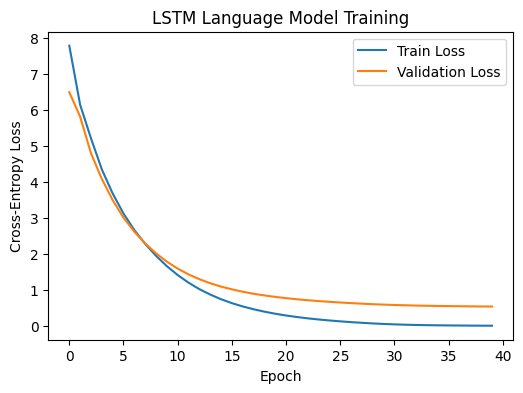

Exposure:  13.2877

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=single | SecretModeType=semantic | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic hints for single PIN (John, 1234)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/40 | Train Loss=7.780 | Val Loss=6.498 | Val PPL=664.00
Epoch 2/40 | Train Loss=6.144 | Val Loss=5.818 | Val PPL=336.20
Epoch 3/40 | Train Loss=5.214 | Val Loss=4.804 | Val PPL=121.98
Epoch 4/40 | Train Loss=4.353 | Val Loss=4.093 | Val PPL=59.90
Epoch 5/40 | Train Loss=3.684 | Val Loss=3.507 | Val PPL=33.34
Epoch 6/40 | Train Loss=3.127 | Val Loss=3.018 | Val PPL=20.46
Epoch 7/40 | Train Loss=2.669 | Val Loss=2.629 | Val PPL=13.87
Epoch 8/40 | Train Loss=2.287 | Val Loss=2.306 | Val PPL=10.03
Epoch 9/40 | Train Loss=

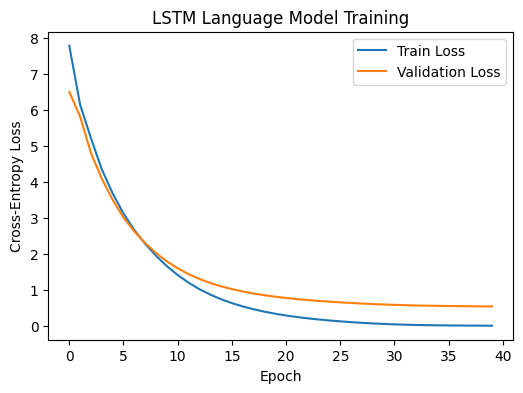

Exposure:   2.2036

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=single | SecretModeType=direct | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH PIN secrets (single)


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0


/content/drive/MyDrive/cs699_project/scripts/train_lstm_ptb.py:215: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP] Epoch 1/100 | Train=9.881 | Val=9.861 | PPL=19165.25
[DP] Epoch 2/100 | Train=9.838 | Val=9.810 | PPL=18205.89
[DP] Epoch 3/100 | Train=9.770 | Val=9.716 | PPL=16581.57
[DP] Epoch 4/100 | Train=9.624 | Val=9.484 | PPL=13143.99
[DP] Epoch 5/100 | Train=9.160 | Val=8.608 | PPL=5474.53
[DP] Epoch 6/100 | Train=8.178 | Val=7.842 | PPL=2545.25
[DP] Epoch 7/100 | Train=7.749 | Val=7.587 | PPL=1972.76
[DP] Epoch 8/100 | Train=7.549 | Val=7.444 | PPL=1709.54
[DP] Epoch 9/100 | Train=7.403 | Val=7.328 | PPL=1522.40
[DP] Epoch 10/100 | Train=7.288 | Val=7.234 | PPL=1386.31
[DP] Epoch 11/100 | Train=7.225 | Val=7.154 | PPL=1279.61
[DP] Epoch 12/100 | Train=7.120 | Val=7.087 | PPL=1195.75
[DP] Epoch 13/100 | Train=7.047 | Val=7.028 | PPL=1127.31
[DP] Epoch 14/100 | Train=6.988 | Val=6.971 | PPL=1065.44
[DP] Epoch 15/100 | Train=6.942 | Val=6.918 | PPL=1009.96
[DP] Epoch 16/100 | Train=6.914 | Val=6.863 | PPL=955.77
[DP] Epoch 17/100 | Train=6.846 | Val=6.808 | PPL=905.00
[DP] Epoch 18/100 | T

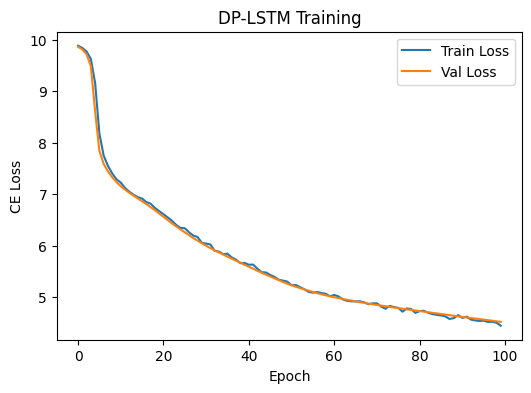

Exposure:   0.0077

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=single | SecretModeType=semantic | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic hints for single PIN (John, 1234)


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0
[DP] Epoch 1/100 | Train=9.881 | Val=9.861 | PPL=19165.65
[DP] Epoch 2/100 | Train=9.838 | Val=9.810 | PPL=18207.42
[DP] Epoch 3/100 | Train=9.770 | Val=9.716 | PPL=16584.71
[DP] Epoch 4/100 | Train=9.624 | Val=9.484 | PPL=13150.46
[DP] Epoch 5/100 | Train=9.159 | Val=8.609 | PPL=5483.23
[DP] Epoch 6/100 | Train=8.178 | Val=7.844 | PPL=2551.64
[DP] Epoch 7/100 | Train=7.749 | Val=7.589 | PPL=1977.28
[DP] Epoch 8/100 | Train=7.549 | Val=7.446 | PPL=1713.07
[DP] Epoch 9/100 | Train=7.403 | Val=7.330 | PPL=1525.69
[DP] Epoch 10/100 | Train=7.288 | Val=7.237 | PPL=1389.47
[DP] Epoch 11/100 | Train=7.225 | Val=7.157 | PPL=1282.60
[DP] Epoch 12/100 | Train=7.120 | Val=7.089 | PPL=1198.72
[DP] Epoch 13/100 | Train=7.049 | Val=7.030 | PPL=1130.28
[DP] Epoch 14/100 | Train=6.989 | 

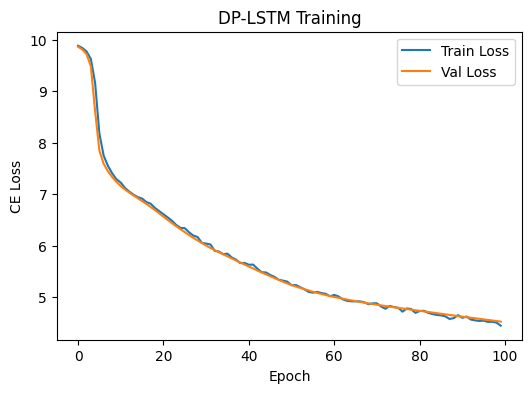

Exposure:   0.0016

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=multiple | SecretModeType=direct | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH PIN secrets (multiple)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/40 | Train Loss=7.783 | Val Loss=6.507 | Val PPL=670.07
Epoch 2/40 | Train Loss=6.147 | Val Loss=5.828 | Val PPL=339.60
Epoch 3/40 | Train Loss=5.217 | Val Loss=4.814 | Val PPL=123.24
Epoch 4/40 | Train Loss=4.355 | Val Loss=4.102 | Val PPL=60.47
Epoch 5/40 | Train Loss=3.687 | Val Loss=3.516 | Val PPL=33.64
Epoch 6/40 | Train Loss=3.130 | Val Loss=3.026 | Val PPL=20.62
Epoch 7/40 | Train Loss=2.671 | Val Loss=2.637 | Val PPL=13.97
Epoch 8/40 | Train Loss=2.289 | Val Loss=2.313 | Val PPL=10.10
Epoch 9/40 | Train Loss=1.958 | Val Loss=2.038

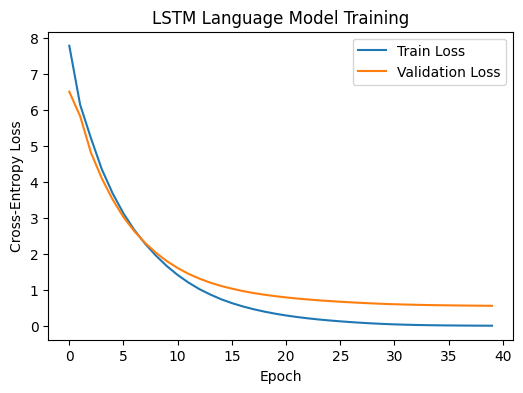

Exposure:  10.9658

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=multiple | SecretModeType=semantic | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic numeric hints for multi PIN (John + other people)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/40 | Train Loss=7.782 | Val Loss=6.511 | Val PPL=672.65
Epoch 2/40 | Train Loss=6.148 | Val Loss=5.831 | Val PPL=340.85
Epoch 3/40 | Train Loss=5.220 | Val Loss=4.824 | Val PPL=124.43
Epoch 4/40 | Train Loss=4.362 | Val Loss=4.114 | Val PPL=61.21
Epoch 5/40 | Train Loss=3.695 | Val Loss=3.530 | Val PPL=34.12
Epoch 6/40 | Train Loss=3.139 | Val Loss=3.042 | Val PPL=20.94
Epoch 7/40 | Train Loss=2.680 | Val Loss=2.652 | Val PPL=14.18
Epoch 8/40 | Train Loss=2.296 | Val Loss=2.328 | Val PPL=10.25
Epoch 

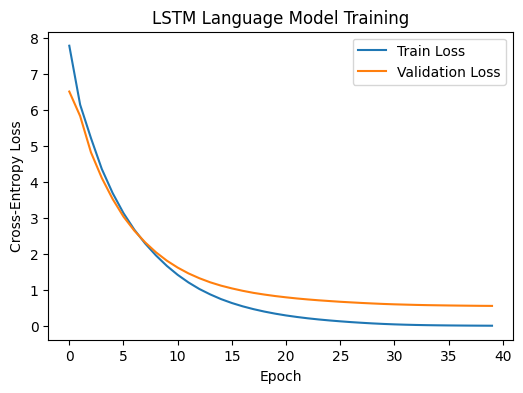

Exposure:   2.2304

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=multiple | SecretModeType=direct | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH PIN secrets (multiple)


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0
[DP] Epoch 1/100 | Train=9.881 | Val=9.861 | PPL=19167.74
[DP] Epoch 2/100 | Train=9.838 | Val=9.810 | PPL=18213.74
[DP] Epoch 3/100 | Train=9.771 | Val=9.717 | PPL=16599.67
[DP] Epoch 4/100 | Train=9.625 | Val=9.487 | PPL=13187.81
[DP] Epoch 5/100 | Train=9.163 | Val=8.620 | PPL=5543.75
[DP] Epoch 6/100 | Train=8.182 | Val=7.855 | PPL=2577.44
[DP] Epoch 7/100 | Train=7.751 | Val=7.599 | PPL=1995.94
[DP] Epoch 8/100 | Train=7.551 | Val=7.455 | PPL=1728.67
[DP] Epoch 9/100 | Train=7.405 | Val=7.339 | PPL=1539.65
[DP] Epoch 10/100 | Train=7.292 | Val=7.246 | PPL=1402.16
[DP] Epoch 11/100 | Train=7.227 | Val=7.166 | PPL=1294.84
[DP] Epoch 12/100 | Train=7.122 | Val=7.099 | PPL=1210.29
[DP] Epoch 13/100 | Train=7.050 | Val=7.040 | PPL=1141.12
[DP] Epoch 14/100 | Train=6.992 | 

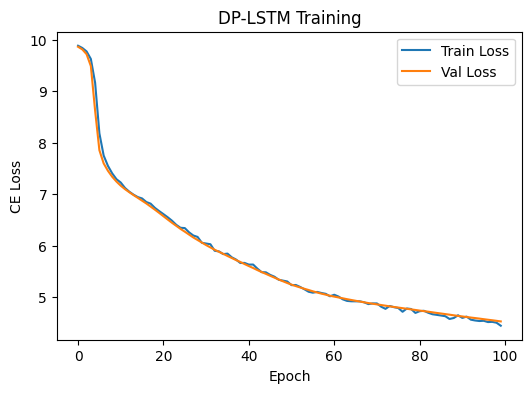

Exposure:   0.0074

RUN: Embedding=bert1024 | SecretType=pin | SecretMode=multiple | SecretModeType=semantic | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic numeric hints for multi PIN (John + other people)


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0
[DP] Epoch 1/100 | Train=9.881 | Val=9.861 | PPL=19167.61
[DP] Epoch 2/100 | Train=9.838 | Val=9.810 | PPL=18214.68
[DP] Epoch 3/100 | Train=9.771 | Val=9.717 | PPL=16601.76
[DP] Epoch 4/100 | Train=9.625 | Val=9.488 | PPL=13194.68
[DP] Epoch 5/100 | Train=9.164 | Val=8.623 | PPL=5556.87
[DP] Epoch 6/100 | Train=8.183 | Val=7.857 | PPL=2584.39
[DP] Epoch 7/100 | Train=7.753 | Val=7.601 | PPL=2000.12
[DP] Epoch 8/100 | Train=7.551 | Val=7.456 | PPL=1731.02
[DP] Epoch 9/100 | Train=7.405 | Val=7.341 | PPL=1541.67
[DP] Epoch 10/100 | Train=7.292 | Val=7.247 | PPL=1404.00
[DP] Epoch 11/100 | Train=7.229 | Val=7.167 | PPL=1295.94
[DP] Epoch 12/100 | Train=7.123 | Val=7.099 | PPL=1211.17
[DP] Epoch 13/100 | Train=7.052 | Val=7.040 | PPL=1141.94
[DP] Epoch 14/100 | Train=6.993 | 

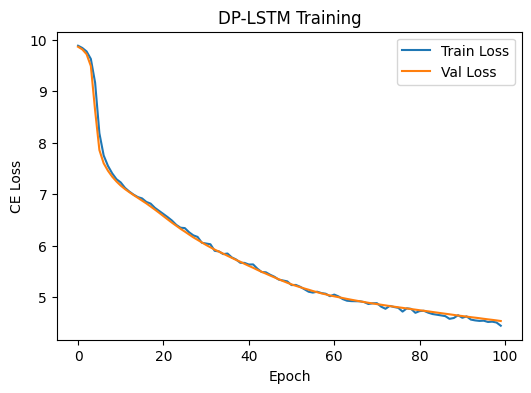

Exposure:   0.0016

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=single | SecretModeType=direct | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH disease secrets (single)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/5 | Train Loss=7.780 | Val Loss=6.492 | Val PPL=659.96
Epoch 2/5 | Train Loss=6.143 | Val Loss=5.813 | Val PPL=334.50
Epoch 3/5 | Train Loss=5.214 | Val Loss=4.799 | Val PPL=121.41
Epoch 4/5 | Train Loss=4.352 | Val Loss=4.088 | Val PPL=59.59
Epoch 5/5 | Train Loss=3.683 | Val Loss=3.501 | Val PPL=33.14


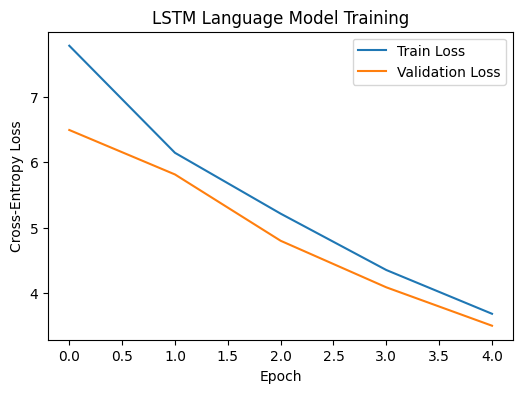

Exposure:   4.7901

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=single | SecretModeType=semantic | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic hints for single disease (John, alzheimers)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/5 | Train Loss=7.781 | Val Loss=6.494 | Val PPL=661.28
Epoch 2/5 | Train Loss=6.144 | Val Loss=5.814 | Val PPL=334.88
Epoch 3/5 | Train Loss=5.214 | Val Loss=4.800 | Val PPL=121.54
Epoch 4/5 | Train Loss=4.353 | Val Loss=4.089 | Val PPL=59.66
Epoch 5/5 | Train Loss=3.684 | Val Loss=3.502 | Val PPL=33.19


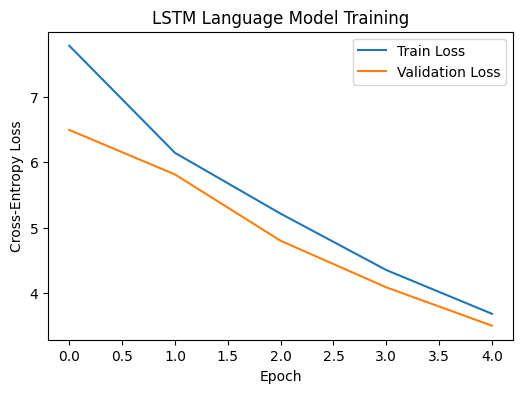

Exposure:   1.9827

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=single | SecretModeType=direct | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH disease secrets (single)


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0
[DP] Epoch 1/12 | Train=9.881 | Val=9.861 | PPL=19165.25
[DP] Epoch 2/12 | Train=9.838 | Val=9.810 | PPL=18205.88
[DP] Epoch 3/12 | Train=9.770 | Val=9.716 | PPL=16581.51
[DP] Epoch 4/12 | Train=9.624 | Val=9.484 | PPL=13143.79
[DP] Epoch 5/12 | Train=9.159 | Val=8.608 | PPL=5473.97
[DP] Epoch 6/12 | Train=8.178 | Val=7.842 | PPL=2545.10
[DP] Epoch 7/12 | Train=7.749 | Val=7.587 | PPL=1972.64
[DP] Epoch 8/12 | Train=7.549 | Val=7.444 | PPL=1709.41
[DP] Epoch 9/12 | Train=7.403 | Val=7.328 | PPL=1522.28
[DP] Epoch 10/12 | Train=7.288 | Val=7.234 | PPL=1386.21
[DP] Epoch 11/12 | Train=7.225 | Val=7.154 | PPL=1279.51
[DP] Epoch 12/12 | Train=7.120 | Val=7.086 | PPL=1195.68
[DP] (ε=32.72, δ=2e-05)


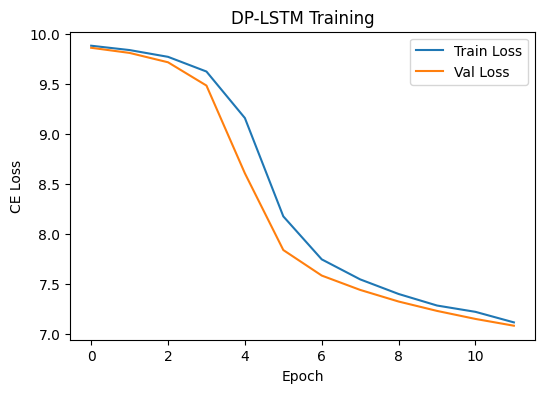

Exposure:   4.0531

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=single | SecretModeType=semantic | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic hints for single disease (John, alzheimers)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu


[DP] σ=0.44  C=1.0
[DP] Epoch 1/12 | Train=9.881 | Val=9.861 | PPL=19165.07
[DP] Epoch 2/12 | Train=9.838 | Val=9.810 | PPL=18206.26
[DP] Epoch 3/12 | Train=9.770 | Val=9.716 | PPL=16582.87
[DP] Epoch 4/12 | Train=9.624 | Val=9.484 | PPL=13147.39
[DP] Epoch 5/12 | Train=9.160 | Val=8.609 | PPL=5481.80
[DP] Epoch 6/12 | Train=8.178 | Val=7.843 | PPL=2548.61
[DP] Epoch 7/12 | Train=7.749 | Val=7.588 | PPL=1975.16
[DP] Epoch 8/12 | Train=7.550 | Val=7.445 | PPL=1711.50
[DP] Epoch 9/12 | Train=7.403 | Val=7.329 | PPL=1524.10
[DP] Epoch 10/12 | Train=7.288 | Val=7.235 | PPL=1387.77
[DP] Epoch 11/12 | Train=7.225 | Val=7.155 | PPL=1280.93
[DP] Epoch 12/12 | Train=7.120 | Val=7.088 | PPL=1197.05
[DP] (ε=32.72, δ=2e-05)


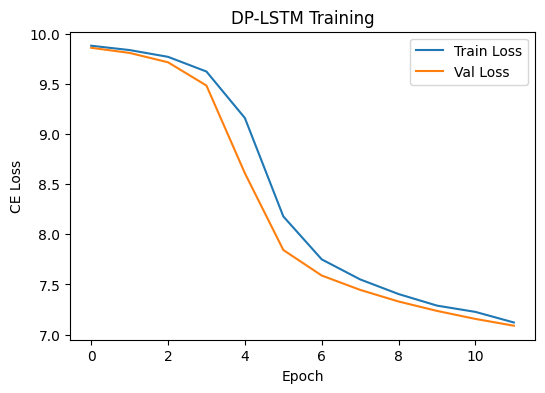

Exposure:   4.0531

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=multiple | SecretModeType=direct | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH disease secrets (multiple)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/5 | Train Loss=7.781 | Val Loss=6.505 | Val PPL=668.17
Epoch 2/5 | Train Loss=6.144 | Val Loss=5.824 | Val PPL=338.40
Epoch 3/5 | Train Loss=5.214 | Val Loss=4.810 | Val PPL=122.77
Epoch 4/5 | Train Loss=4.353 | Val Loss=4.099 | Val PPL=60.27
Epoch 5/5 | Train Loss=3.684 | Val Loss=3.512 | Val PPL=33.51


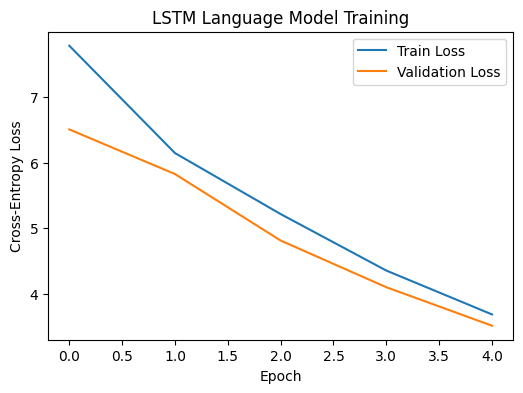

Exposure:   4.7901

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=multiple | SecretModeType=semantic | DP=False
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic hints for multi disease (John + other people)
Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
Using device: cpu
Epoch 1/5 | Train Loss=7.782 | Val Loss=6.508 | Val PPL=670.72
Epoch 2/5 | Train Loss=6.147 | Val Loss=5.827 | Val PPL=339.30
Epoch 3/5 | Train Loss=5.218 | Val Loss=4.815 | Val PPL=123.35
Epoch 4/5 | Train Loss=4.356 | Val Loss=4.103 | Val PPL=60.52
Epoch 5/5 | Train Loss=3.687 | Val Loss=3.516 | Val PPL=33.64


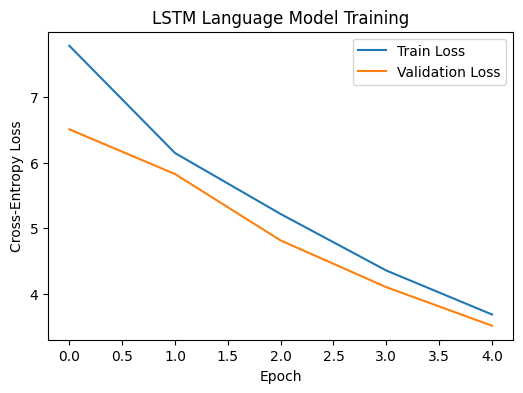

Exposure:   2.0531

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=multiple | SecretModeType=direct | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using DIRECT secret insertion.
Training WITH disease secrets (multiple)


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0
[DP] Epoch 1/12 | Train=9.881 | Val=9.861 | PPL=19165.86
[DP] Epoch 2/12 | Train=9.838 | Val=9.810 | PPL=18210.48
[DP] Epoch 3/12 | Train=9.771 | Val=9.717 | PPL=16593.34
[DP] Epoch 4/12 | Train=9.624 | Val=9.486 | PPL=13171.46
[DP] Epoch 5/12 | Train=9.160 | Val=8.615 | PPL=5515.77
[DP] Epoch 6/12 | Train=8.179 | Val=7.851 | PPL=2568.99
[DP] Epoch 7/12 | Train=7.750 | Val=7.596 | PPL=1989.96
[DP] Epoch 8/12 | Train=7.549 | Val=7.452 | PPL=1722.56
[DP] Epoch 9/12 | Train=7.403 | Val=7.335 | PPL=1533.21
[DP] Epoch 10/12 | Train=7.289 | Val=7.241 | PPL=1395.41
[DP] Epoch 11/12 | Train=7.226 | Val=7.161 | PPL=1287.82
[DP] Epoch 12/12 | Train=7.120 | Val=7.093 | PPL=1203.34
[DP] (ε=32.72, δ=2e-05)


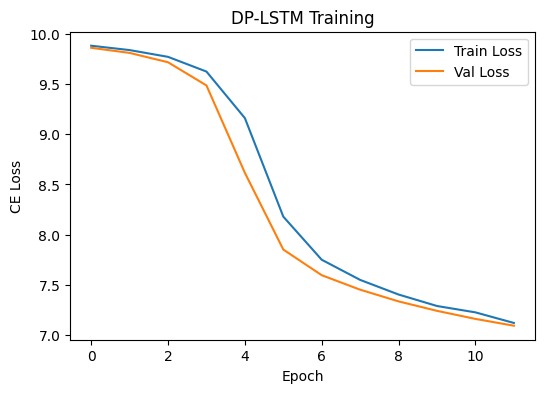

Exposure:   4.0531

RUN: Embedding=bert1024 | SecretType=disease | SecretMode=multiple | SecretModeType=semantic | DP=True
PTB loaded: train=1027251 tokens, valid=81364, test=92844 tokens
>> Using SEMANTIC secret insertion.
Training WITH semantic hints for multi disease (John + other people)


Vocabulary built: 19772 tokens.
   Vocab size: 19772
Loading embeddings from /content/drive/MyDrive/cs699_project/embeddings/bert1024_baseline.pt
Dataset size: 2000 sequences
[DP] Using device: cpu
[DP] σ=0.44  C=1.0
[DP] Epoch 1/12 | Train=9.881 | Val=9.861 | PPL=19166.86
[DP] Epoch 2/12 | Train=9.838 | Val=9.810 | PPL=18210.91
[DP] Epoch 3/12 | Train=9.771 | Val=9.717 | PPL=16592.54
[DP] Epoch 4/12 | Train=9.624 | Val=9.486 | PPL=13169.08
[DP] Epoch 5/12 | Train=9.161 | Val=8.615 | PPL=5512.01
[DP] Epoch 6/12 | Train=8.180 | Val=7.850 | PPL=2566.54
[DP] Epoch 7/12 | Train=7.751 | Val=7.596 | PPL=1990.92
[DP] Epoch 8/12 | Train=7.551 | Val=7.453 | PPL=1724.55
[DP] Epoch 9/12 | Train=7.404 | Val=7.337 | PPL=1535.70
[DP] Epoch 10/12 | Train=7.290 | Val=7.243 | PPL=1398.16
[DP] Epoch 11/12 | Train=7.226 | Val=7.163 | PPL=1290.40
[DP] Epoch 12/12 | Train=7.121 | Val=7.095 | PPL=1205.77
[DP] (ε=32.72, δ=2e-05)


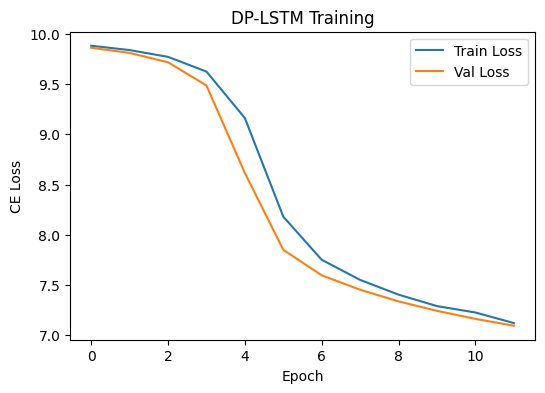

Exposure:   4.0531


In [ ]:
results = []
for emb, sec, mode, use_dp, mode_type  in all_combinations:
    base_epochs = 5 if sec == "disease" else 40
    epochs = int(base_epochs * 2.5) if use_dp else base_epochs
    args = Args(embedding_type=emb, secret_type=sec, secret_mode=mode, epochs=epochs, dp=use_dp, secret_mode_type=mode_type)
    result = run_one_experiment(args)
    results.append(result)

In [ ]:
print("\n" + "="*70)
print("ALL RESULTS")
print("="*70)
print_results_table(results)


ALL RESULTS

Embedding    | Secret   | Insert    | DP  | SecretModeType  | Exposure  | Rank   | Epsilon 
-------------------------------------------------------------------------------------------
bert1024     | pin      | single    | No  | direct          |   13.2877 |      1 |        -
bert1024     | pin      | single    | No  | semantic        |    2.2036 |   2171 |        -
bert1024     | pin      | single    | Yes | direct          |    0.0077 |   9947 |   117.13
bert1024     | pin      | single    | Yes | semantic        |    0.0016 |   9989 |   117.13
bert1024     | pin      | multiple  | No  | direct          |   10.9658 |      5 |        -
bert1024     | pin      | multiple  | No  | semantic        |    2.2304 |   2131 |        -
bert1024     | pin      | multiple  | Yes | direct          |    0.0074 |   9949 |   117.13
bert1024     | pin      | multiple  | Yes | semantic        |    0.0016 |   9989 |   117.13
bert1024     | disease  | single    | No  | direct          |    4

In [ ]:
import csv

csv_file_name = "experiment_results.csv"

if results:
    fieldnames = results[0].keys()

    with open(csv_file_name, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    print(f"Results saved to {csv_file_name}")
else:
    print("No results to save.")

Results saved to experiment_results.csv
